In [ ]:
import openai

# Set your API key
openai.api_key = "your-api-key"

In [ ]:
# Setup for langchain RAG
%pip install langchain_community tiktoken langchain-openai langchainhub chromadb langchain python-dotenv

In [7]:
import json, os
from langchain_core.documents import Document
from langchain.vectorstores import Chroma
from langchain.embeddings import OpenAIEmbeddings

class RAGHelper:
    def __init__(self):
        self.fpath = "ucs_website.json"
        self.persist_directory = "rag/chroma_db"
        self.topk = 3
        self.data = self.load_json()
        self.index_to_chroma() # Index once

    def load_json(self):
        # Load JSON file into a Python dictionary.
        if not os.path.exists(self.fpath):
            raise FileNotFoundError(f"JSON file not found at {self.fpath}")

        with open(self.fpath, "r", encoding="utf-8") as f:
            return json.load(f)

    def normalize_text(self, txt):
        # Clean text by removing escape characters and extra whitespace.
        for c in ['\r', '\n']:
            txt = txt.replace(c, ' ')
        
        txt = re.sub(r'\s+', ' ', txt)

        return txt.strip()

    def convert_to_documents(self):
        # Convert the loaded JSON into a list of LangChain Document objects.
        documents = []

        # Top-level sections like counselling, appointment, etc.
        for section_key, content in self.data.items():
            if section_key in ["url", "appointment_link"]:
                continue
            
            title = content.get("title", "")
            section_text = content.get("section", "")
            full_text = f"{title}\n{section_text}"
            normalized = self.normalize_text(full_text)
            
            documents.append(Document(
                page_content=normalized,
                metadata={"source_section": section_key, "title": title}
            ))

        return documents

    def index_to_chroma(self):
        # Split documents and index them into ChromaDB vector store.
        documents = self.convert_to_documents()
        splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
        split_docs = splitter.split_documents(documents)

        vectorstore = Chroma.from_documents(
            documents=split_docs,
            embedding=OpenAIEmbeddings(),
            persist_directory=self.persist_directory
        )

        return vectorstore

    def retrieve(self, query):
        vectorstore = Chroma(
            persist_directory=self.persist_directory,
            embedding_function=OpenAIEmbeddings()
        )

        retriever = vectorstore.as_retriever(search_kwargs={"k": self.topk})
        retrieved_docs = retriever.get_relevant_documents(query=query)

        # Build structured context
        context_blocks = []

        for doc in retrieved_docs:
            title = doc.metadata.get("title", "Untitled Section")
            text = doc.page_content.strip()
            block = f"{title}:\n{text}"
            context_blocks.append(block)
        
        context = "\n".join(context_blocks)
            
        # context = "\n\n".join(doc.page_content for doc in retrieved_docs)

        rag_prompt = """
        You have access to the following structured information extracted from NUS's University Counselling Services website. The content is grouped into titled sections:

        {context}

        A user has asked the following question:

        "{question}"

        Your task is to:

        1. Provide a clear, concise, and empathetic answer to the user's question.
        2. For each section in the context, briefly explain how it is relevant (or not) to answering the user's concern.
        3. Extract and list **all** helpful contact information such as phone numbers, email addresses, appointment links, app names, or physical addresses mentioned in the context.
        4. Organize your response bullet points to ensure readability.

        Ensure your tone is kind and understanding. Where multiple resources exist, sort your response according to the most appropriate one at the top for their described issue. If there are repeat information, do not repeat, show unique values.

        Helpful and Empathetic Answer:
        """

        final_prompt = rag_prompt.format(context=context, question=query)
        
        return final_prompt


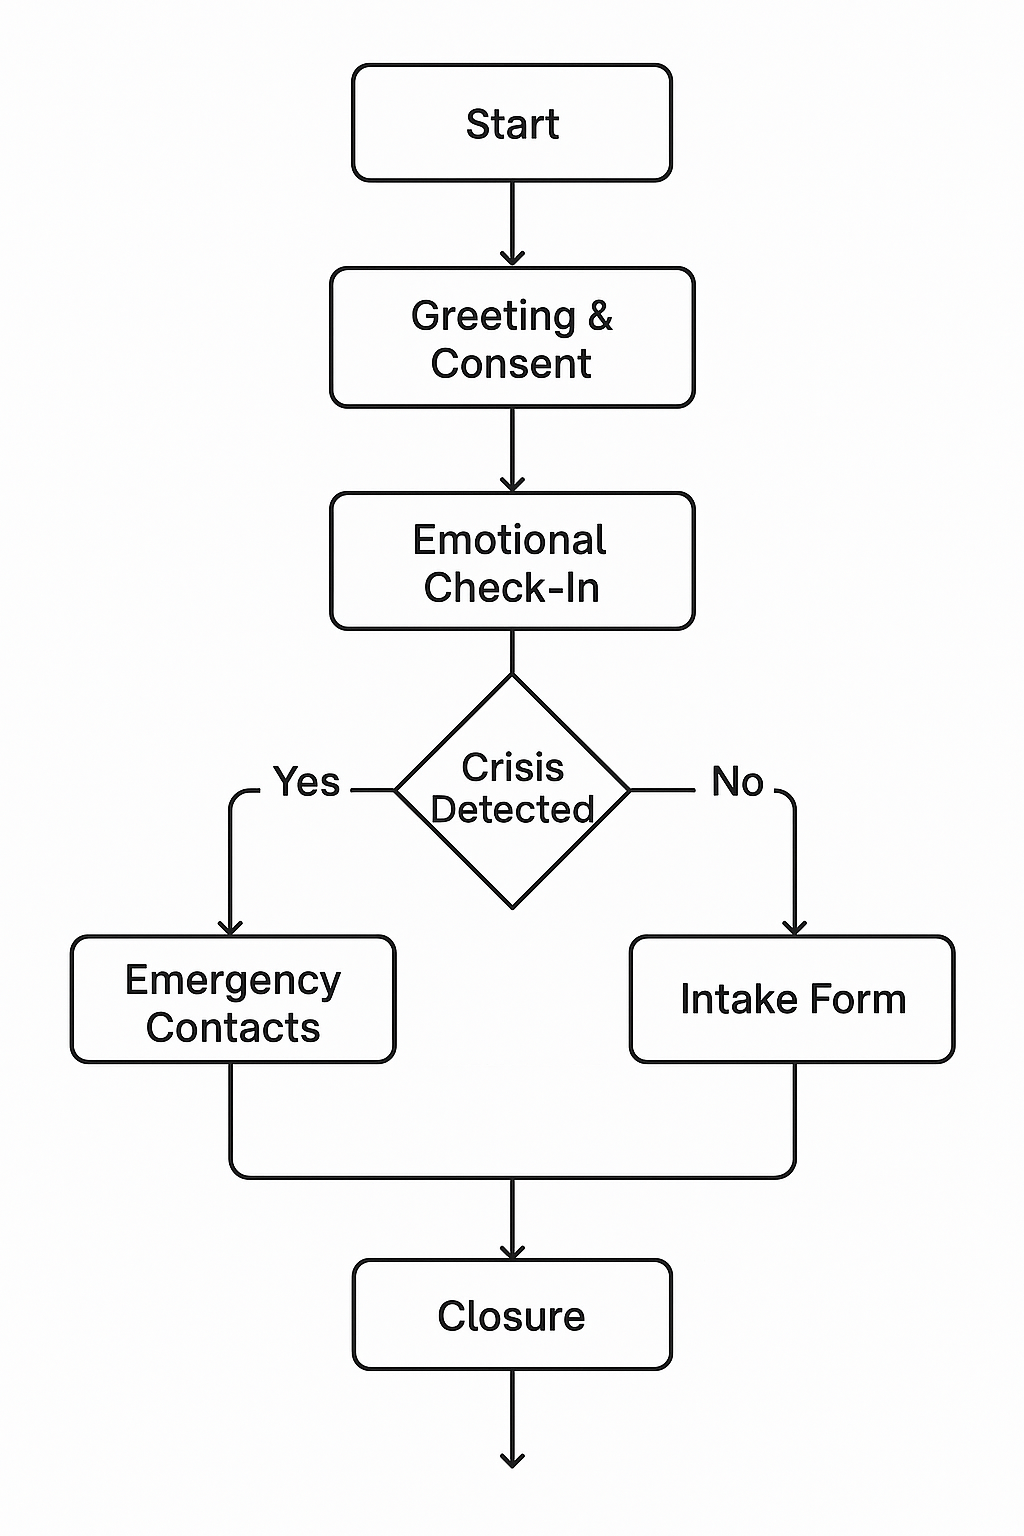

In [8]:
class MentalHealthChatAgent:
    def __init__(self):
        self.messages = [
            {"role": "system", "content": """
You are a mental health intake assistant.
You always reply to user/patient gently and warmly.
You must always reply with special tags to guide the system's action:
- <START> if starting a new session
- <CONSENT> if greeting and ask for consent of asking question and the chatting data privacy policy before intake form filling.
- <FAQ> if user asks questions about services
- <EMERGENCY> if user shows signs of crisis or severe emotional distress
- <INTAKE> if strating or continuing intake form:
    - Add <BEGIN> if to start the intake filling
    - Add <NEXT> if ready to move to the next section of the intake form
    - Add <CONTINUE> if keep on the current section
    - Add <FINISH> if all intake question completed
- <END> if the the session is end
Always embed these tags at in your response.
The chatting session flow for making appointment with mental health counselling session is:
- Normal case: Greet → Consent → Emotional Check-in → Intake Form Questions → Confirm → Close → Done.
- Ask each quseiton one by one in short sentance, keep each section short and concise for finishing the session in 10 mins.
- If no consent, ask again or close the session.
- If user asks questions: Reply with <FAQ> tag → Answer → Return to intake form.
- If emergency detected: Reply with <EMERGENCY> tag → Provide immediate crisis contact → End intake form politely → End the session.
"""
            },
            {"role": "assistant", "content": "<START> Hello! I'm here to support you. Before scheduling an appointment, may I ask you a few questions to better understand your situation?"}
        ]
        self.intake_question_index = 0
        self.intake_form_data = {}
        self.intake_section = [
            "<INTAKE><BEGIN> Section 1. General Information: Name and Contact.",
            "<INTAKE><NEXT> Section 2. Main issue and past history.",
            "<INTAKE><NEXT> Section 3. Symptom Check: Decreased need for sleep, Change in appetite, Anxiety attacks, etc.",
            "<INTAKE><NEXT> Section 4. Risk Assessment: suicide risk, family violance, rist of harm to others.",
            "<INTAKE><NEXT> Section 5. Medical History.",
            "<INTAKE><NEXT> Section 6. Appointment check: time, prefer phsician."
        ]
        self.topk = 3
        self.rag_helper = RAGHelper()


    def chat(self, messages = None):
        if not messages:
            messages=self.messages
        client= openai.OpenAI(api_key=openai.api_key)
        response = client.chat.completions.create(
            model="gpt-4-turbo",  # or gpt-4-turbo if you want cheaper
            messages=messages
        )
        reply = response.choices[0].message.content
        return reply

    def parse_reply(self, reply):
        if "<FAQ>" in reply:
            ## use RAG to regerate answer
            self.handle_faq(reply)
        elif "<EMERGENCY>" in reply:
            # use RAG to generate emergency handling answer
            self.handle_emergency()
        elif "<INTAKE>"in reply:
            if "<NEXT>" in reply or "<BEGIN>" in reply or "<FINISHED>" in reply:
                # inject intake section to lead the question to ask
                reply = self.ask_next_intake_question()
                if "<FINISHED>" in reply:
                    self.submit_intake_form()
        elif "<END>" in reply:
            self.end_session()

        return reply

    def handle_faq(self, reply):
        print("[SYSTEM] FAQ detected. Retrieving answer...")
        # TODO: Call your RAG retriever here
        # could include contact, acaliable time table etc.
        # thinking to copy content from school web: https://www.nus.edu.sg/hwb/ucs/
        # prompt = rag_helper.retrieve("I'm feeling overwhelmed and anxious. What support is available?")
        last_user_input = self.messages[-1]["content"]
        faq_prompt = self.rag_helper.retrieve(last_user_input)

        self.messages.append({"role": "user", "content": faq_prompt})
        llm_reply = self.chat()
        print(f"[DEBUG] Handle FAQ: \n User Asked: {last_user_input}\nAssistant: {llm_reply}")
        # reply=self.parse_reply(AI_reply)
        # self.messages.append({"role": "assistant", "content": reply})
        # print(f"Agent: {reply}")


    def handle_emergency(self):
        print("[SYSTEM] Emergency detected! Providing crisis lifeline...")
        print("If you are in immediate danger, please call 24/7 Lifeline: 1-800-273-TALK (8255)")
        print("A real counselor will follow up shortly. Please stay safe.")
        # TODO: Optionally halt further conversation
        # considering more solidate way to detect emergency, as it is important and can not make mistakes.

    def ask_next_intake_question(self):
        if self.intake_question_index < len(self.intake_section):
            question = self.intake_section[self.intake_question_index]
            self.intake_question_index += 1
            self.messages.append({"role": "assistant", "content":question})
            reply = self.chat()
            return reply
        else:
            return "<FINISH> All intake questions completed."

    def submit_intake_form(self):
        print("[SYSTEM] Submitting intake form...")
        print(self.intake_form_data)  # Simulate form submission
        # TODO: generate final intake form result.
        self.end_session()

    def end_session(self):
        # save the session
        self.submit_intake_form()
        print("[SYSTEM] Session ended. Thank you.")
        

    def start_session(self):
        print("Hello! I'm here to support you. Before scheduling an appointment, may I ask you a few questions to better understand your situation?")
        while True:
            user_input = input("You: ")
            self.messages.append({"role": "user", "content": user_input})
            AI_reply = self.chat()
            print(f"[DEBUG] Assistant: {AI_reply}")
            reply=self.parse_reply(AI_reply)
            self.messages.append({"role": "assistant", "content": reply})
            print(f"Agent: {reply}")
            # print(f"Messages\n\n {self.messages[1:]}")
            if "<END>" in reply:
                break


In [9]:
agent = MentalHealthChatAgent()

if not os.path.exists("rag/chroma_db"):
    os.makedirs("rag/chroma_db")

# I'm feeling overwhelmed and anxious. What support is available?

agent.start_session()


Hello! I'm here to support you. Before scheduling an appointment, may I ask you a few questions to better understand your situation?
[DEBUG] Assistant: <FAQ> It's completely understandable to feel overwhelmed and anxious. We offer various support services, including individual counseling, therapeutic groups, and workshops aimed at managing anxiety and stress effectively. Our licensed professionals can work with you to determine the best approach tailored to your needs. Would you like to continue with setting up an appointment to discuss these options in more detail?
[SYSTEM] FAQ detected. Retrieving answer...
[DEBUG] Handle FAQ: 
 User Asked: I'm feeling overwhelmed and anxious. What support is available?
Assistant: <FAQ> I'm sorry to hear that you're feeling overwhelmed and anxious. You're not alone, and it's great that you're reaching out for support. At NUS, you have access to a variety of resources that can help:

**During Office Hours:**
- **NUS Counselling Centre:** You can seek 

RecursionError: maximum recursion depth exceeded